<a href="https://colab.research.google.com/github/JacobeJonathan/ML/blob/main/Clase_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase Gratuita: Machine Learning

In [ ]:
1+1

2

In [ ]:
ADN = "CGATCGATCGATCGATCGATC"
edad = 45

In [ ]:
ADN.count("A")

5

In [ ]:
# %GC
GC = ADN.count("G") + ADN.count("C")
GC / len(ADN) * 100


52.38095238095239

## 1. Importar los datos

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/LuisPerezTimana/LyN-Biolearning/refs/heads/main/MachineLearning/cancer_mama_GEO.csv"

df = pd.read_csv(url, index_col = 0)
df

,A1BG,A1BG-AS1,A2M,A2M-AS1,A2ML1,A4GALT,AAAS,AACS,AADAT,AAED1,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,Subtipo
Muestra,,,,,,,,,,,,,,,,,,,,,
GSM1116084,4.03351,4.07321,11.86630,2.79242,4.03857,4.32402,6.08457,8.49674,7.76972,8.58744,...,10.73830,2.95666,6.46484,6.192982,8.02576,9.408820,8.119970,5.459560,7.487000,Basal
GSM1116085,3.83607,3.43643,11.38760,2.91200,4.95422,4.39671,5.66057,8.06314,7.86438,8.23673,...,10.94770,2.63201,6.36116,6.944594,1.75204,8.184363,8.342235,4.939115,7.207630,Basal
GSM1116086,4.75083,4.13960,10.91170,3.60725,1.94443,4.35259,6.18629,8.15857,5.54774,8.76785,...,10.12040,2.50384,5.95332,6.540436,3.91524,8.332867,9.376165,6.033735,6.667170,Her2
GSM1116087,4.16247,3.71923,14.76230,4.56842,2.42399,4.73874,6.23308,7.67429,6.90157,8.78876,...,10.55730,2.73655,6.87482,5.627458,6.14618,8.066076,8.506430,5.403675,7.147015,Basal
GSM1116088,3.93765,3.50428,9.25403,2.89978,1.83775,4.42066,6.14399,8.89622,5.16418,8.41371,...,10.21680,2.77189,6.99560,6.777994,2.91927,7.711490,8.575460,5.362665,6.074440,Her2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1116234,4.31301,3.65063,10.49730,3.27184,1.79298,4.48159,6.96680,7.29140,5.63765,8.03798,...,6.98219,2.89905,6.67568,6.172236,3.25270,8.018300,7.503110,5.190690,7.002460,Luminal A
GSM1116235,4.29187,4.08125,11.29030,3.27169,1.78683,4.47048,6.52868,8.39675,5.72607,9.02670,...,6.31463,2.92737,6.74893,6.109262,3.38645,8.156033,8.825175,5.720090,7.451405,Luminal A
GSM1116236,4.59683,3.58078,11.25310,3.27049,1.79342,4.62714,5.96674,8.67160,5.72556,6.90406,...,9.64245,3.76203,7.81022,6.723640,3.76587,7.757517,7.937150,5.501625,7.024440,Luminal B


In [ ]:
df["Subtipo"].value_counts() # Frecuencias de las categorias

,count
Subtipo,
Basal,41
Her2,30
Luminal B,30
Luminal A,29


## 2. Seleccionar variables


In [ ]:
X = df.drop(columns = "Subtipo") # Drop: elimina la columna
y = df["Subtipo"]
y

,Subtipo
Muestra,
GSM1116084,Basal
GSM1116085,Basal
GSM1116086,Her2
GSM1116087,Basal
GSM1116088,Her2
...,...
GSM1116234,Luminal A
GSM1116235,Luminal A
GSM1116236,Luminal B


## 3. Training - Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)
X_train.shape

(97, 13823)

## 4. MODELO: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

#modelo = RandomForestClassifier(max_depth=2) modelo con pocas capas de profundidad
modelo = RandomForestClassifier()
modelo.fit(X_train, y_train)

RandomForestClassifier()

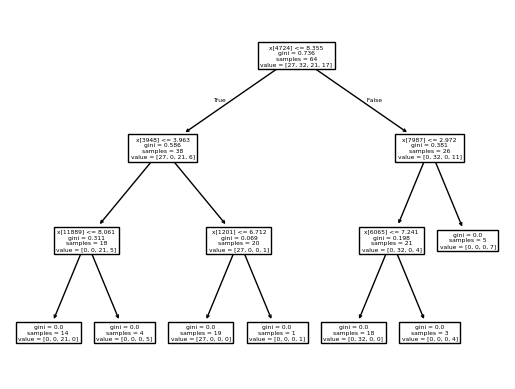

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plot_tree(modelo.estimators_[0])
plt.show()

## 5. Predecir datos de evaluación

In [ ]:
predicciones = modelo.predict(X_test)
predicciones

array(['Basal', 'Luminal B', 'Luminal B', 'Luminal A', 'Luminal B',
       'Luminal B', 'Luminal B', 'Luminal B', 'Her2', 'Basal', 'Basal',
       'Her2', 'Luminal A', 'Basal', 'Her2', 'Luminal A', 'Luminal B',
       'Basal', 'Basal', 'Basal', 'Basal', 'Luminal B', 'Basal', 'Her2',
       'Luminal B', 'Basal', 'Basal', 'Her2', 'Basal', 'Luminal B',
       'Her2', 'Luminal B', 'Basal'], dtype=object)

In [ ]:
resultado = pd.DataFrame({
    "Real": y_test,
    "Predicho": predicciones
})

resultado

,Real,Predicho
Muestra,,
GSM1116109,Basal,Basal
GSM1116198,Luminal B,Luminal B
GSM1116197,Luminal B,Luminal B
GSM1116228,Luminal A,Luminal A
GSM1116237,Luminal B,Luminal B
GSM1116212,Luminal B,Luminal B
GSM1116211,Luminal B,Luminal B
GSM1116236,Luminal B,Luminal B
GSM1116137,Her2,Her2


In [ ]:
## Métricas de evaluación

from sklearn.metrics import accuracy_score

accuracy_score(y_test, predicciones)


0.9696969696969697

### MATRIZ DE CONFUSION

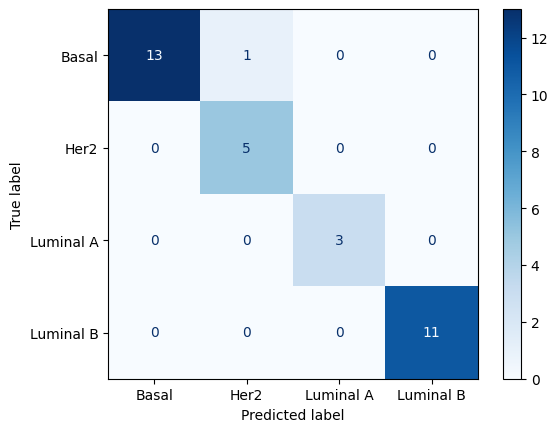

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, predicciones, cmap = "Blues")

### Importancia

In [ ]:
importancia = pd.Series(modelo.feature_importances_, index = X.columns)
importancia

,0
A1BG,0.0
A1BG-AS1,0.0
A2M,0.0
A2M-AS1,0.0
A2ML1,0.0
...,...
ZYG11A,0.0
ZYG11B,0.0
ZYX,0.0
ZZEF1,0.0


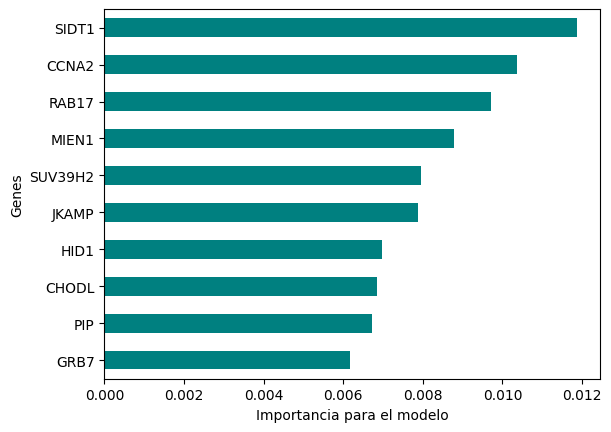

In [ ]:
mejores = importancia.nlargest(10)
mejores.sort_values().plot.barh(color = "teal")
plt.xlabel("Importancia para el modelo")
plt.ylabel("Genes")
plt.show()